In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
path_2012 = r"/home/renan/renan/escola/PY/atividade_6/Tabela5-sem_emprego_2012.csv"
path_2026 = r"/home/renan/renan/escola/PY/atividade_6/Tabela5-sem_emprego_2026.csv"
path_1_1_1 = r"/home/renan/renan/escola/PY/atividade_6/Tabela 1.1.1.xls"

t2012 = pd.read_csv(path_2012, encoding="utf-8-sig", sep=";", decimal=",")
t2026 = pd.read_csv(path_2026, encoding="utf-8-sig", sep=";", decimal=",")
indicador_1 = pd.read_excel(path_1_1_1, engine="xlrd")

In [11]:
t2012

,Sigla,Código,Estado,Desocupados - homens (2012 T1),Desocupados - mulheres (2012 T1)
0,AC,12,Acre,45.3,54.7
1,AL,27,Alagoas,44.7,55.3
2,AM,13,Amazonas,47.5,52.5
3,AP,16,Amapá,48.1,51.9
4,BA,29,Bahia,43.8,56.2
5,CE,23,Ceará,51.1,48.9
6,DF,53,Distrito Federal,41.0,59.0
7,ES,32,Espírito Santo,46.4,53.6
8,GO,52,Goiás,41.0,59.0
9,MA,21,Maranhão,47.2,52.8


In [12]:
t2026

,Sigla,Código,Estado,Desocupados - homens (2026 T1),Desocupados - mulheres (2026 T1)
0,AC,12,Acre,53.2,46.8
1,AL,27,Alagoas,50.7,49.3
2,AM,13,Amazonas,46.8,53.2
3,AP,16,Amapá,51.1,48.9
4,BA,29,Bahia,44.7,55.3
5,CE,23,Ceará,52.7,47.3
6,DF,53,Distrito Federal,47.9,52.1
7,ES,32,Espírito Santo,47.5,52.5
8,GO,52,Goiás,47.5,52.5
9,MA,21,Maranhão,49.1,50.9


In [13]:
comp = t2012.merge(t2026, on=["Sigla", "Código", "Estado"], how="inner")
comp

,Sigla,Código,Estado,Desocupados - homens (2012 T1),Desocupados - mulheres (2012 T1),Desocupados - homens (2026 T1),Desocupados - mulheres (2026 T1)
0,AC,12,Acre,45.3,54.7,53.2,46.8
1,AL,27,Alagoas,44.7,55.3,50.7,49.3
2,AM,13,Amazonas,47.5,52.5,46.8,53.2
3,AP,16,Amapá,48.1,51.9,51.1,48.9
4,BA,29,Bahia,43.8,56.2,44.7,55.3
5,CE,23,Ceará,51.1,48.9,52.7,47.3
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5
8,GO,52,Goiás,41.0,59.0,47.5,52.5
9,MA,21,Maranhão,47.2,52.8,49.1,50.9


In [14]:
comp["dif_homens"] = comp["Desocupados - homens (2026 T1)"] - comp["Desocupados - homens (2012 T1)"]
comp["dif_mulheres"] = comp["Desocupados - mulheres (2026 T1)"] - comp["Desocupados - mulheres (2012 T1)"]

comp.sort_values("dif_mulheres", ascending=False)

,Sigla,Código,Estado,Desocupados - homens (2012 T1),Desocupados - mulheres (2012 T1),Desocupados - homens (2026 T1),Desocupados - mulheres (2026 T1),dif_homens,dif_mulheres
20,RO,11,Rondônia,43.4,56.6,33.0,67.0,-10.4,10.4
26,TO,17,Tocantins,55.3,44.7,46.2,53.8,-9.1,9.1
24,SE,28,Sergipe,46.5,53.5,40.3,59.7,-6.2,6.2
19,RN,24,Rio Grande do Norte,51.0,49.0,48.2,51.8,-2.8,2.8
11,MS,50,Mato Grosso do Sul,47.2,52.8,45.3,54.7,-1.9,1.9
12,MT,51,Mato Grosso,44.1,55.9,42.8,57.2,-1.3,1.3
2,AM,13,Amazonas,47.5,52.5,46.8,53.2,-0.7,0.7
25,SP,35,São Paulo,45.4,54.6,46.2,53.8,0.8,-0.8
4,BA,29,Bahia,43.8,56.2,44.7,55.3,0.9,-0.9
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5,1.1,-1.1


In [15]:
aumento_mulheres = comp.sort_values("dif_mulheres", ascending=False)[
    ["Estado", "Desocupados - mulheres (2012 T1)", "Desocupados - mulheres (2026 T1)", "dif_mulheres"]
]
aumento_mulheres

,Estado,Desocupados - mulheres (2012 T1),Desocupados - mulheres (2026 T1),dif_mulheres
20,Rondônia,56.6,67.0,10.4
26,Tocantins,44.7,53.8,9.1
24,Sergipe,53.5,59.7,6.2
19,Rio Grande do Norte,49.0,51.8,2.8
11,Mato Grosso do Sul,52.8,54.7,1.9
12,Mato Grosso,55.9,57.2,1.3
2,Amazonas,52.5,53.2,0.7
25,São Paulo,54.6,53.8,-0.8
4,Bahia,56.2,55.3,-0.9
7,Espírito Santo,53.6,52.5,-1.1


In [16]:
queda_mulheres = comp.sort_values("dif_mulheres")[
    ["Estado", "Desocupados - mulheres (2012 T1)", "Desocupados - mulheres (2026 T1)", "dif_mulheres"]
]
queda_mulheres

,Estado,Desocupados - mulheres (2012 T1),Desocupados - mulheres (2026 T1),dif_mulheres
0,Acre,54.7,46.8,-7.9
6,Distrito Federal,59.0,52.1,-6.9
8,Goiás,59.0,52.5,-6.5
1,Alagoas,55.3,49.3,-6.0
17,Paraná,59.7,53.7,-6.0
10,Minas Gerais,56.9,51.4,-5.5
13,Pará,56.8,51.7,-5.1
15,Pernambuco,56.1,51.3,-4.8
22,Rio Grande do Sul,57.2,52.6,-4.6
14,Paraíba,55.6,51.1,-4.5


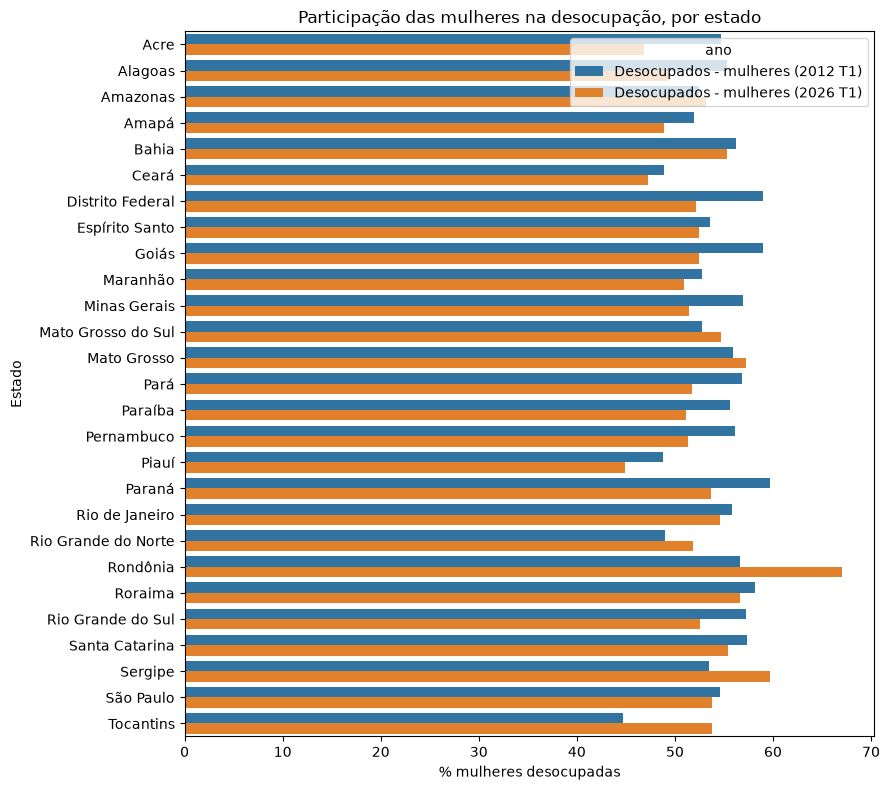

In [17]:
comp_long = comp.melt(
    id_vars="Estado",
    value_vars=["Desocupados - mulheres (2012 T1)", "Desocupados - mulheres (2026 T1)"],
    var_name="ano",
    value_name="percentual",
)

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(data=comp_long, y="Estado", x="percentual", hue="ano", ax=ax)
ax.set_title("Participação das mulheres na desocupação, por estado")
ax.set_xlabel("% mulheres desocupadas")
ax.set_ylabel("Estado")
plt.tight_layout()
plt.show()

In [18]:
bruto = pd.read_excel(path_1_1_1, engine="xlrd", header=None)

indicador_1 = bruto.iloc[8:41].copy()
indicador_1.columns = [
    "uf_regiao",
    "total",
    "total_branca",
    "total_preta_parda",
    "homem_branca",
    "homem_preta_parda",
    "mulher_branca",
    "mulher_preta_parda",
]
indicador_1 = indicador_1.reset_index(drop=True)

for col in indicador_1.columns[1:]:
    indicador_1[col] = pd.to_numeric(indicador_1[col], errors="coerce")

indicador_1

,uf_regiao,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
0,Brasil,16.985781,16.545930,17.333142,11.705136,11.746330,20.404106,22.037998
1,Norte,16.187037,15.925246,16.256032,11.588653,11.514646,19.295780,20.534188
2,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410
3,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
4,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
5,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244
6,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.835110,21.591144
7,Amapá,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487
8,Tocantins,15.815781,15.701788,15.768728,10.733863,11.682616,19.663713,19.629399
9,Nordeste,18.499396,18.151700,18.610911,11.723907,11.848436,22.744666,23.716716


In [19]:
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]

estados = indicador_1[~indicador_1["uf_regiao"].isin(["Brasil"] + regioes)]
estados

,uf_regiao,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
2,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410
3,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
4,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
5,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244
6,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.835110,21.591144
7,Amapá,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487
8,Tocantins,15.815781,15.701788,15.768728,10.733863,11.682616,19.663713,19.629399
10,Maranhão,16.669614,16.421773,16.708894,11.665173,11.437359,19.881056,20.739589
11,Piauí,17.960366,16.948094,18.231789,12.258324,11.204814,20.494063,23.695440
12,Ceará,19.499293,18.527120,19.882469,12.186936,12.821323,23.019718,24.952274


In [20]:
cruzado = comp.merge(estados, left_on="Estado", right_on="uf_regiao", how="inner")
cruzado = cruzado.drop(columns=["uf_regiao"])

print(f"Estados na comparação 2012 x 2026: {len(comp)}")
print(f"Estados na Tabela 1.1.1: {len(estados)}")
print(f"Estados cruzados: {len(cruzado)}")
cruzado

Estados na comparação 2012 x 2026: 27
Estados na Tabela 1.1.1: 27
Estados cruzados: 27


,Sigla,Código,Estado,Desocupados - homens (2012 T1),Desocupados - mulheres (2012 T1),Desocupados - homens (2026 T1),Desocupados - mulheres (2026 T1),dif_homens,dif_mulheres,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
0,AC,12,Acre,45.3,54.7,53.2,46.8,7.9,-7.9,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
1,AL,27,Alagoas,44.7,55.3,50.7,49.3,6.0,-6.0,20.217129,19.165111,20.560451,12.121839,13.357160,24.093655,25.856637
2,AM,13,Amazonas,47.5,52.5,46.8,53.2,-0.7,0.7,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
3,AP,16,Amapá,48.1,51.9,51.1,48.9,3.0,-3.0,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487
4,BA,29,Bahia,43.8,56.2,44.7,55.3,0.9,-0.9,17.849776,17.538007,17.935566,10.551673,10.982808,22.572730,23.217119
5,CE,23,Ceará,51.1,48.9,52.7,47.3,1.6,-1.6,19.499293,18.527120,19.882469,12.186936,12.821323,23.019718,24.952274
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1,6.9,-6.9,15.096351,15.061306,15.126295,11.377952,10.481279,17.738123,19.307332
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5,1.1,-1.1,17.111106,16.510610,17.478861,11.798571,12.017589,20.464462,22.196626
8,GO,52,Goiás,41.0,59.0,47.5,52.5,6.5,-6.5,15.186471,14.962622,15.296966,10.636424,10.531883,18.440842,19.587913
9,MA,21,Maranhão,47.2,52.8,49.1,50.9,1.9,-1.9,16.669614,16.421773,16.708894,11.665173,11.437359,19.881056,20.739589


In [21]:
cruzado.to_csv(r"H:\dados30\python-tecTI\dados\geral.csv", sep=";", index=False)

In [22]:
cruzado[["dif_mulheres", "total", "mulher_branca", "mulher_preta_parda"]].corr()

,dif_mulheres,total,mulher_branca,mulher_preta_parda
dif_mulheres,1.000000,0.097579,0.098347,0.102935
total,0.097579,1.000000,0.954207,0.976472
mulher_branca,0.098347,0.954207,1.000000,0.942171
mulher_preta_parda,0.102935,0.976472,0.942171,1.000000


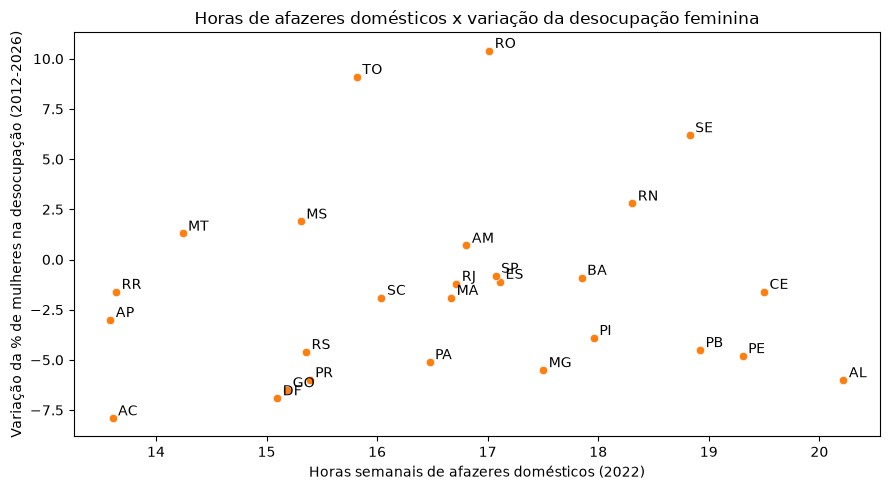

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=cruzado, x="total", y="dif_mulheres", ax=ax)

for _, row in cruzado.iterrows():
    ax.annotate(row["Sigla"], (row["total"], row["dif_mulheres"]), textcoords="offset points", xytext=(4, 2))

sns.scatterplot(data=cruzado, x="total", y="dif_mulheres", ax=ax)
ax.set_title("Horas de afazeres domésticos x variação da desocupação feminina")
ax.set_xlabel("Horas semanais de afazeres domésticos (2022)")
ax.set_ylabel("Variação da % de mulheres na desocupação (2012-2026)")
plt.tight_layout()
plt.show()